In [1]:
import jax 
jax.config.update("jax_enable_x64", True)
import numpy as np
import matplotlib.pyplot as plt
import atmo3 as a3 
import cmocean as cmo
import os

In [2]:
import jax.numpy as jnp

## Grid parameters

In [3]:
nside_grid = 128
box_length_in_m = 10000.0
site_altitude = 5110.0  # Atacama altitude in meters
injection_scale_in_m = 200.0  # Injection scale in meters
UTC_hour = 20 # Example UTC hour for the Atacama site
P_surface = 58800.  # Surface pressure in Pa or kg/(m.s^2)

print(f"Initializing atmosphere with nside_grid={nside_grid} and box_length_in_m={box_length_in_m} and site_altitude={site_altitude} meters")
atmo = a3.Atmosphere(
        nside_grid=nside_grid, 
        box_length_in_m=box_length_in_m,
        site_altitude=site_altitude,  # Atacama altitude in meters
        )

Initializing atmosphere with nside_grid=128 and box_length_in_m=10000.0 and site_altitude=5110.0 meters


Creating power spectrum for specific humidity normalized to 1.

In [4]:
k_array     = np.arange(nside_grid) * atmo.grid_wsp.dk
# Based on the Kolmogorov spectrum, we can define a power spectrum based on values from Morris et al. (2025) (arxiv:2410.13064)
k0          = 2*np.pi / injection_scale_in_m
pofk_array  = ( k0**2. + k_array**2 )**-(11/6)
pofk_array /= np.max(pofk_array)  # Normalize the power spectrum to 1
pspec = {'k': k_array, 'pofk': pofk_array}

Creating rescaling factors for the grid...

In [5]:
mean_q_profile  = np.load('./mean_q_profiles_2023_07.npz')['typical_profiles']   # kg/kg
delta_q_profile = np.load('./delta_q_profiles_2023_07.npz')['delta_q_map'] # kg/kg
mean_ta_profile = np.load('./mean_ta_profiles_2023_07.npz')['typical_profiles']   # K
altitude        = np.load('./delta_q_profiles_2023_07.npz')['alt_grid']    # m

rescale_delta_q = {'h': altitude, 'f': delta_q_profile[UTC_hour]}
rescale_mean_q  = {'h': altitude, 'f': mean_q_profile[UTC_hour]}
rescale_mean_t  = {'h': altitude, 'f': mean_ta_profile[UTC_hour]}

Adding component: specific humidity with unit kg/kg

In [6]:
atmo.add_component(
    field_name='specific humidity',
    field_unit='kg/kg',
    pspec=pspec,
    rescale=rescale_delta_q,
    mean=rescale_mean_q,
    seed=123456789,
)

atmo.add_property(
    property_name='temperature',
    property_unit='K',
    property_value=rescale_mean_t
)

Generating realization for the component...

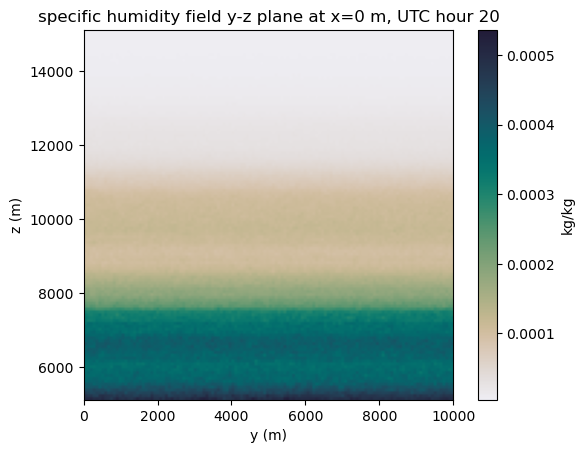

In [7]:
atmo.generate_realization(time_step=0)

plt.imshow(
    atmo.components['specific humidity'].field[0, :, :].T,
    extent=(0, box_length_in_m, site_altitude, site_altitude + box_length_in_m),
    cmap=cmo.cm.rain, origin='lower', vmin=atmo.components['specific humidity'].field.min(), vmax=atmo.components['specific humidity'].field.max()
)
plt.colorbar(label='kg/kg')
plt.title(f"specific humidity field y-z plane at x=0 m, UTC hour {UTC_hour}")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()


Computing dependent fields: virtual temperature, pressure, water vapor density, and precipitable water vapor...

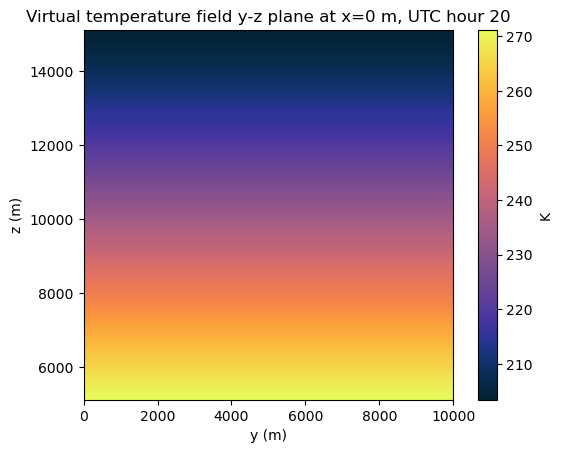

In [8]:
atmo.compute_virtual_temperature()

plt.imshow(
    atmo.components['virtual temperature'].field[0, :, :].T,
    extent=(0, box_length_in_m, site_altitude, site_altitude + box_length_in_m),
    cmap=cmo.cm.thermal, origin='lower', vmin=atmo.components['virtual temperature'].field.min(), vmax=atmo.components['virtual temperature'].field.max()
)
plt.colorbar(label='K')
plt.title(f"Virtual temperature field y-z plane at x=0 m, UTC hour {UTC_hour}")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

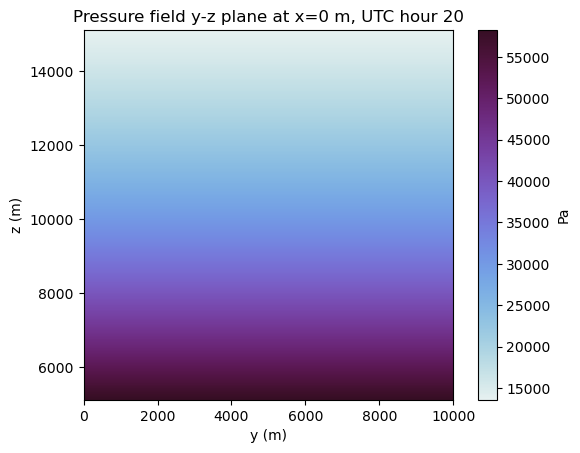

In [9]:
atmo.compute_pressure(P_surface=P_surface)  # Surface pressure in Pa

plt.imshow(
    atmo.components['pressure'].field[0, :, :].T,
    extent=(0, box_length_in_m, site_altitude, site_altitude + box_length_in_m),
    cmap=cmo.cm.dense, origin='lower', vmin=atmo.components['pressure'].field.min(), vmax=atmo.components['pressure'].field.max()
)
plt.colorbar(label='Pa')
plt.title(f"Pressure field y-z plane at x=0 m, UTC hour {UTC_hour}")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

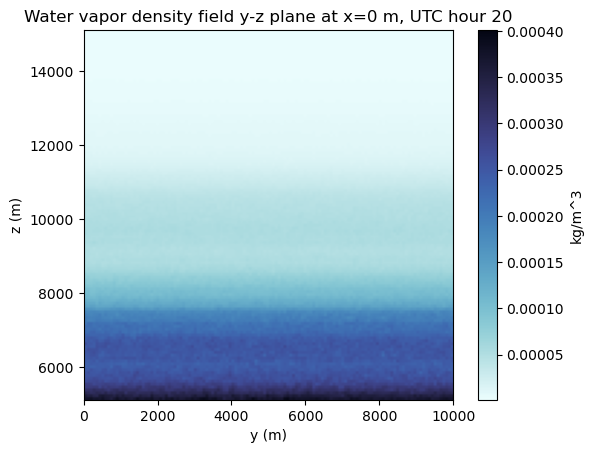

In [10]:
atmo.compute_water_vapor_density()
plt.imshow(
    atmo.components['water vapor density'].field[0, :, :].T,
    extent=(0, box_length_in_m, site_altitude, site_altitude + box_length_in_m),
    cmap=cmo.cm.ice_r, origin='lower', vmin=atmo.components['water vapor density'].field.min(), vmax=atmo.components['water vapor density'].field.max()
)
plt.colorbar(label='kg/m^3')
plt.title(f"Water vapor density field y-z plane at x=0 m, UTC hour {UTC_hour}")
plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.show()

In [11]:
pwv_cube = atmo.components['water vapor density'].field

In [12]:
pwv_cube.shape

(128, 128, 128)

## Let's do the LOS integration!

Define insrument static position and pointing

In [13]:
theta = 10.0  # degrees
phi = 30.0  # degrees
gamma_tol = 2.  # degrees
tolerance = jnp.cos(jnp.deg2rad(gamma_tol))
# detector_position = jnp.array(
#     [4 / 7 * atmo.Lbox, 2 / 7 * atmo.Lbox, site_altitude]
# )
detector_position = jnp.array(
    [0, 0, 0]
)
unit_pointing_vec_reference = atmo.grid_wsp.lonlat_to_unitvec(theta, phi, lonlat=True)

## Plotting utils

In [14]:
import plotly.graph_objects as go

In [15]:
def add_axis(fig, start, direction, length, color="black", width=8, arrow_frac=0.1):
    """
    Add a 3D axis line to a Plotly figure.

    Parameters
    ----------
    fig : go.Figure
        The Plotly 3D figure.
    start : tuple of 3 floats
        (x, y, z) starting point of the axis.
    direction : str
        Axis direction: 'x', 'y', or 'z'.
    length : float
        Length of the axis line.
    color : str, optional
        Line color. Default is 'black'.
    width : float, optional
        Line width. Default is 8.
    arrow_frac : float, optional
        Fraction of the line to allocate for arrowhead.
    """
    x_det, y_det, z_det = start

    if direction == "x":
        x = [x_det, x_det + length]
        y = [y_det, y_det]
        z = [z_det, z_det]
        unit_vec = jnp.array([1, 0, 0])
    elif direction == "y":
        x = [x_det, x_det]
        y = [y_det, y_det + length]
        z = [z_det, z_det]
        unit_vec = jnp.array([0, 1, 0])
    elif direction == "z":
        x = [x_det, x_det]
        y = [y_det, y_det]
        z = [z_det, z_det + length]
        unit_vec = jnp.array([0, 0, 1])
    else:
        raise ValueError(f"Unknown direction: {direction}")

    norm_vec = unit_vec / jnp.linalg.norm(unit_vec) * length

    tip = jnp.array([x_det, y_det, z_det]) + norm_vec

    fig.add_trace(
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="lines",
            line=dict(color=color, width=width),
            showlegend=False,
        )
    )

    # Arrowhead: small lines forming a "V"
    arrow_len = length * arrow_frac
    # Pick two perpendicular vectors to direction
    if jnp.allclose(norm_vec[:2], 0):
        perp1 = jnp.array([1, 0, 0])
    else:
        perp1 = jnp.array([-norm_vec[1], norm_vec[0], 0])
    perp1 = perp1 / jnp.linalg.norm(perp1) * arrow_len

    perp2 = jnp.cross(norm_vec, perp1)
    perp2 = perp2 / jnp.linalg.norm(perp2) * arrow_len

    for vec in [perp1, -perp1, perp2, -perp2]:
        fig.add_trace(
            go.Scatter3d(
                x=[tip[0], tip[0] - vec[0]],
                y=[tip[1], tip[1] - vec[1]],
                z=[tip[2], tip[2] - vec[2]],
                mode="lines",
                line=dict(color=color, width=width),
                showlegend=False,
            )
        )

In [16]:
def add_cone_mesh(
    fig,
    det_pos,
    unit_pointing_vec_reference,
    gamma_tol,
    cone_length=500.0,
    n_circle=16,
    n_length=10,
    color="blue",
    opacity=0.12,
    name="Cone",
):
    """
    Add a triangular mesh representing a cone (field-of-view) to a Plotly Figure.

    Parameters
    ----------
    fig : plotly.graph_objects.Figure
        Figure to draw the mesh into (modified in-place).
    det_pos : array-like (3,)
        Detector position in the same coordinate system as the cone (i,j,k or meters).
    unit_pointing_vec_reference : array-like (3,)
        Unit vector for pointing direction.
    gamma_tol : float
        Cone half-angle in degrees.
    cone_length : float, optional
        Length of the cone (default: 500.0).
    n_circle : int, optional
        Number of points around each circular layer (default: 16).
    n_length : int, optional
        Number of layers along the cone length (default: 10).
    color : str, optional
        Mesh color.
    opacity : float, optional
        Mesh opacity.
    name : str, optional
        Legend name for the mesh.

    Returns
    -------
    verts : ndarray
        Array of vertices shape (n_circle*n_length, 3)
    faces : ndarray
        Array of triangle faces shape (n_triangles, 3)
    """
    det_pos = jnp.asarray(det_pos)
    u = jnp.asarray(unit_pointing_vec_reference)

    # choose a reference vector not parallel to u
    ref = jnp.array([0, 0, 1])
    if jnp.isclose(jnp.abs(jnp.dot(u, ref)), 1.0):
        ref = jnp.array([0, 1, 0])

    e1 = jnp.cross(u, ref)
    e1 = e1 / jnp.linalg.norm(e1)
    e2 = jnp.cross(u, e1)

    t_vals = jnp.linspace(0, cone_length, n_length)
    phi_vals = jnp.linspace(0, 2 * jnp.pi, n_circle, endpoint=False)

    vertices = []
    for t in t_vals:
        R = t * jnp.tan(jnp.deg2rad(gamma_tol))
        for phi in phi_vals:
            point = det_pos + u * t + R * (jnp.cos(phi) * e1 + jnp.sin(phi) * e2)
            vertices.append(point)

    vertices = jnp.asarray(vertices)
    x, y, z = vertices.T

    # build faces connecting layer i to i+1
    faces = []
    for i in range(n_length - 1):
        for j in range(n_circle):
            j_next = (j + 1) % n_circle
            a = i * n_circle + j
            b = i * n_circle + j_next
            c = (i + 1) * n_circle + j
            d = (i + 1) * n_circle + j_next
            faces.append([a, b, c])
            faces.append([b, d, c])
    faces = jnp.asarray(faces)

    # Add mesh to figure
    fig.add_trace(
        go.Mesh3d(
            x=x,
            y=y,
            z=z,
            i=faces[:, 0].astype(int),
            j=faces[:, 1].astype(int),
            k=faces[:, 2].astype(int),
            color=color,
            opacity=opacity,
            name=name,
            hoverinfo="skip",
            showscale=False,
        )
    )

    return vertices, faces

In [17]:
cone_length = 1.01 * atmo.grid_wsp.N
n_circle = 16  # number of points around circle
n_length = 10  # number of layers along the cone

# Build local orthonormal frame for cone base
ref = jnp.array([0, 0, 1])

In [18]:
detector_position_ijk = detector_position / atmo.grid_wsp.grid_spacing
det_pos_i, det_pos_j, det_pos_k = detector_position_ijk

Let's integrate slice by slice

In [19]:
kmin = atmo.grid_wsp.start
kmax = atmo.grid_wsp.end
k_slice = jnp.arange(kmin, kmax)

In [20]:
kmax

128

In [21]:
gamma_tol = 1.  # degrees
tolerance = jnp.cos(jnp.deg2rad(gamma_tol))

## Find tolerance for the farthest pixel

In [22]:
r_max = ((kmax-1/2)*atmo.grid_wsp.grid_spacing-detector_position[2])/jnp.cos(jnp.pi / 2 - jnp.deg2rad(theta))
x_max,y_max,z_max = detector_position + r_max*unit_pointing_vec_reference


In [23]:
z_max

Array(9960.9375, dtype=float64)

In [24]:
x_max%atmo.grid_wsp.grid_spacing/atmo.grid_wsp.grid_spacing,y_max%atmo.grid_wsp.grid_spacing/atmo.grid_wsp.grid_spacing,(z_max)%atmo.grid_wsp.grid_spacing/atmo.grid_wsp.grid_spacing

(Array(0.2129513, dtype=float64),
 Array(0.544216, dtype=float64),
 Array(0.5, dtype=float64))

In [25]:
intersected_voxels_coords = np.array([x_max, y_max, z_max])/atmo.grid_wsp.grid_spacing

In [26]:
intersected_voxels_coords

array([626.2129513, 361.544216 , 127.5      ])

In [27]:
farthest = jnp.floor(intersected_voxels_coords) + (intersected_voxels_coords < jnp.floor(intersected_voxels_coords) + 0.5)


In [28]:
farthest

Array([627., 361., 127.], dtype=float64)

In [29]:
farthest_vertex = jnp.array([farthest])*atmo.grid_wsp.grid_spacing

In [30]:
farthest_vertex.shape

(1, 3)

In [31]:
pointing_farthest  = (farthest_vertex - detector_position) / jnp.linalg.norm(farthest_vertex - detector_position)

In [32]:
pointing_farthest.shape

(1, 3)

In [33]:
separation_angle = jnp.arccos(jnp.dot(unit_pointing_vec_reference, pointing_farthest[0]))

In [34]:
jnp.rad2deg(separation_angle)

Array(0.08051318, dtype=float64)

/var/folders/92/5kdrhyzs645g7s911v9x9w8r0000gp/T/ipykernel_56754/3926187243.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


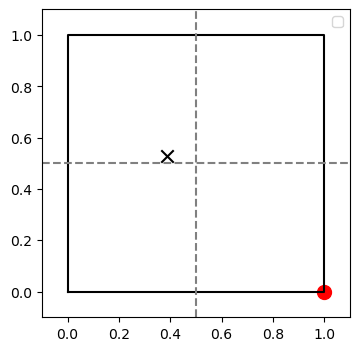

In [35]:
import random

# point aléatoire
x, y = random.random(), random.random()

# sommets du carré
corners = jnp.array([[0,0],[1,0],[0,1],[1,1]])

# distances
d = jnp.sqrt((x - corners[:,0])**2 + (y - corners[:,1])**2)
farthest = np.array(corners[jnp.argmax(d)])

# version "formule" avec jnp.round
formula_corner = np.array([1 - jnp.round(x), 1 - jnp.round(y)])

# tracé
fig, ax = plt.subplots(figsize=(4,4))
ax.plot([0,1,1,0,0],[0,0,1,1,0],'k')
ax.axvline(0.5, ls='--', color='gray')
ax.axhline(0.5, ls='--', color='gray')

ax.scatter(x, y, c='k', marker='x', s=80#, label='point (x,y)'
)
ax.scatter(*farthest, c='r', s=100#, label='sommet le plus éloigné'
)

ax.set_aspect('equal')
ax.set_xlim(-0.1,1.1)
ax.set_ylim(-0.1,1.1)
ax.legend()
# ax.set_title(f"x={x:.2f}, y={y:.2f}\nformule jnp.round → {tuple(formula_corner)}")

plt.show()


In [36]:
atmo.grid_wsp.grid_spacing

78.125

In [37]:
# list_indices_slices = [atmo.grid_wsp.zlayer_to_voxels(
#                         k_layer_center=k,
#                         unit_pointing_vec_reference=unit_pointing_vec_reference,
#                         detector_position=detector_position,
#                         # tolerance=tolerance,
#                         tolerance=jnp.cos(separation_angle),
#                         ) for k in k_slice]

list_indices_slices = [atmo.grid_wsp.zlayer_to_intercepted_voxel(
                        k_layer_center=k,
                        unit_pointing_vec_reference=unit_pointing_vec_reference,
                        detector_position=detector_position,
                        # tolerance=tolerance,
                        #tolerance=jnp.cos(separation_angle),
                        ) for k in k_slice]

In [38]:
intersected_voxels_num = []
for k,index_slice in zip(k_slice, list_indices_slices):
    mask = jnp.any(index_slice > 0, axis=-1)
    intersected_voxels_num.append(len(mask[mask]))
    print(f"Number of voxels intersecting layer {k}: {len(mask[mask])}")

Number of voxels intersecting layer 0: 1
Number of voxels intersecting layer 1: 1
Number of voxels intersecting layer 2: 1
Number of voxels intersecting layer 3: 1
Number of voxels intersecting layer 4: 1
Number of voxels intersecting layer 5: 1
Number of voxels intersecting layer 6: 1
Number of voxels intersecting layer 7: 1
Number of voxels intersecting layer 8: 1
Number of voxels intersecting layer 9: 1
Number of voxels intersecting layer 10: 1
Number of voxels intersecting layer 11: 1
Number of voxels intersecting layer 12: 1
Number of voxels intersecting layer 13: 1
Number of voxels intersecting layer 14: 1
Number of voxels intersecting layer 15: 1
Number of voxels intersecting layer 16: 1
Number of voxels intersecting layer 17: 1
Number of voxels intersecting layer 18: 1
Number of voxels intersecting layer 19: 1
Number of voxels intersecting layer 20: 1
Number of voxels intersecting layer 21: 1
Number of voxels intersecting layer 22: 1
Number of voxels intersecting layer 23: 1
Nu

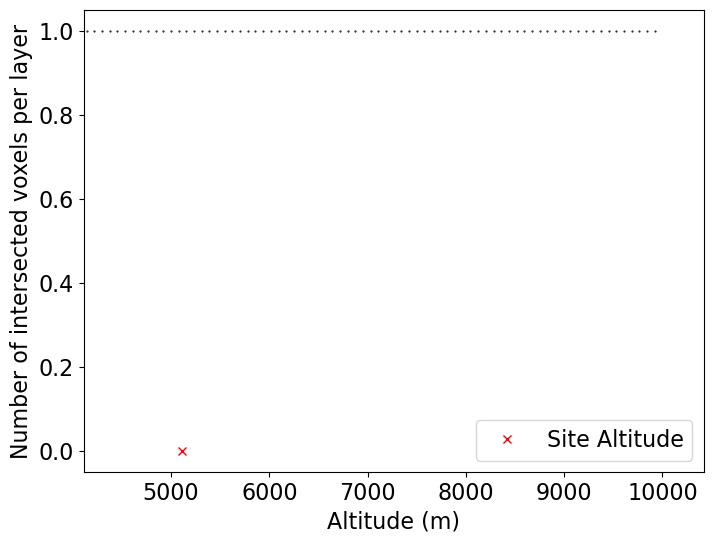

In [39]:
plt.rcParams.update({'font.size': 16})
fig = plt.figure(figsize=(8,6),dpi = 100)
plt.plot(k_slice*atmo.grid_wsp.grid_spacing, intersected_voxels_num,'k.',markersize=1)
plt.plot(site_altitude, 0, 'rx', label='Site Altitude')
plt.xlabel('Altitude (m)')
plt.ylabel('Number of intersected voxels per layer')
plt.xlim(site_altitude-1000)
plt.legend(loc = 'best')
plt.show()


In [40]:
detector_position//atmo.grid_wsp.grid_spacing

Array([0., 0., 0.], dtype=float64)

In [41]:
# voxels_indices_slices = atmo.grid_wsp.zslice_to_voxels(
#     unit_pointing_vec_reference=unit_pointing_vec_reference,
#     detector_position=detector_position,
#     tolerance=tolerance,
# )
voxels_indices_slices = atmo.grid_wsp.zslice_to_intercepted_voxel(
    unit_pointing_vec_reference=unit_pointing_vec_reference,
    detector_position=detector_position,
)

In [42]:
# Step 5: flatten and keep only non-zero centers
# A voxel is non-zero if at least one coordinate > 0
nonzero_mask = jnp.any(voxels_indices_slices > 0, axis=0)
# Extract the selected voxel centers
selected_voxels = voxels_indices_slices[:, nonzero_mask]  # shape (num_selected, 3)

In [43]:
max_radius = atmo.grid_wsp.N * atmo.grid_wsp.grid_spacing - detector_position[2]

In [44]:
max_radius

Array(10000., dtype=float64, weak_type=True)

In [45]:
nonzero_mask.shape

(128, 128, 128)

In [46]:
# mask_radius = jnp.linalg.norm(selected_voxels * atmo.grid_wsp.grid_spacing - detector_position[:, jnp.newaxis], axis=0) <= atmo.grid_wsp.Lbox
mask_radius = jnp.linalg.norm(selected_voxels * atmo.grid_wsp.grid_spacing - detector_position[:, jnp.newaxis], axis=0) <= max_radius

In [47]:
mask_radius

Array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False]

In [48]:
# Create interactive 3D plot with Plotly
fig = go.Figure()



fig.add_trace(
    go.Scatter3d(
        x=selected_voxels[0]*mask_radius,
        y=selected_voxels[1]*mask_radius,
        z=selected_voxels[2]*mask_radius,
        mode="markers",
        marker=dict(size=1, color="black", opacity=0.5),
        name="Center of voxels within separation angle",
        showlegend=True,
    )
)

# Add detector position
fig.add_trace(
    go.Scatter3d(
        x=[det_pos_i],
        y=[det_pos_j],
        z=[det_pos_k],
        mode="markers",
        marker=dict(size=6, color="red", symbol="diamond"),
        name="Detector",
        showlegend=True,
    )
)

# Add detector coordinate axes
axis_len = nside_grid // 10.0


add_axis(fig, (det_pos_i, det_pos_j, det_pos_k), "x", axis_len, color="black")
add_axis(fig, (det_pos_i, det_pos_j, det_pos_k), "y", axis_len, color="black")
add_axis(fig, (det_pos_i, det_pos_j, det_pos_k), "z", axis_len, color="black")

add_cone_mesh(
    fig,
    det_pos=(det_pos_i, det_pos_j, det_pos_k),
    unit_pointing_vec_reference=unit_pointing_vec_reference,
    gamma_tol=gamma_tol,
    cone_length=cone_length,
    n_circle=n_circle,
    n_length=n_length,
    color="royalblue",
    opacity=0.12,
    name=r"Cone of separation angle $\gamma = $" + str(gamma_tol) + "°",
)

fig.update_layout(
    scene=dict(
        xaxis=dict(
            title="X (m)",
            tickmode="array",
            tickvals=list(range(0, nside_grid, nside_grid // 5)),  # voxel indices
            ticktext=[
                f"{val * atmo.grid_wsp.grid_spacing:.0f}" for val in range(0, nside_grid, nside_grid // 5)
            ],  # physical coords
        ),
        yaxis=dict(
            title="Y (m)",
            tickmode="array",
            tickvals=list(range(0, nside_grid + 1, nside_grid // 5)),
            ticktext=[
                f"{val * atmo.grid_wsp.grid_spacing:.0f}" for val in range(0, nside_grid, nside_grid // 5)
            ],
        ),
        zaxis=dict(
            title="Z (m)",
            tickmode="array",
            tickvals=list(range(0, nside_grid + 1, nside_grid // 5)),
            ticktext=[
                f"{val * atmo.grid_wsp.grid_spacing:.0f}" for val in range(0, nside_grid, nside_grid // 5)
            ],
        ),
        aspectmode="cube",
    ),
    title="Interactive 3D Visualization: Detector + Voxel Grid + Line-of-Sight Points in a given layer",
    width=900,
    height=700,
    margin=dict(r=20, b=10, l=10, t=40),
)

# Show the plot
fig.show()

In [103]:
theta

10.0

In [104]:
selected_voxels.shape

(3, 128)

In [105]:
elevation_list = [30.0, 50.0, 70.0, 90.0]

In [106]:
distance_dict = {}
values_pwv_dict = {}

In [107]:
for theta in elevation_list:
    unit_pointing_vec_reference = atmo.grid_wsp.lonlat_to_unitvec(theta, phi, lonlat=True)
    voxels_indices_slices = atmo.grid_wsp.zslice_to_intercepted_voxel(
        unit_pointing_vec_reference=unit_pointing_vec_reference,
        detector_position=detector_position,
    )
    # Step 5: flatten and keep only non-zero centers
    nonzero_mask = jnp.any(voxels_indices_slices > 0, axis=0)
    # Extract the selected voxel centers
    selected_voxels = voxels_indices_slices[:, nonzero_mask]  # shape (num_selected, 3)
    mask_radius = jnp.linalg.norm(selected_voxels * atmo.grid_wsp.grid_spacing - detector_position[:, jnp.newaxis], axis=0) <= max_radius
    selected_voxels = selected_voxels[:, mask_radius]
    print(selected_voxels.shape)
    # Compute radial distances and extract water vapor density values
    # dr = jnp.linalg.norm(jnp.diff(selected_voxels, axis=1), axis=0)*atmo.grid_wsp.grid_spacing
    radius = jnp.linalg.norm(selected_voxels * atmo.grid_wsp.grid_spacing - detector_position[:, jnp.newaxis], axis=0)
    f = pwv_cube[
        (selected_voxels[0]).astype(int),
        (selected_voxels[1]).astype(int),
        (selected_voxels[2]).astype(int)]
    distance_dict[theta] = radius
    values_pwv_dict[theta] = f

(3, 64)
(3, 98)
(3, 120)
(3, 127)


In [108]:
# plt.plot(selected_voxels[2, :-1]*atmo.grid_wsp.grid_spacing, dr, 'k.', markersize=2)

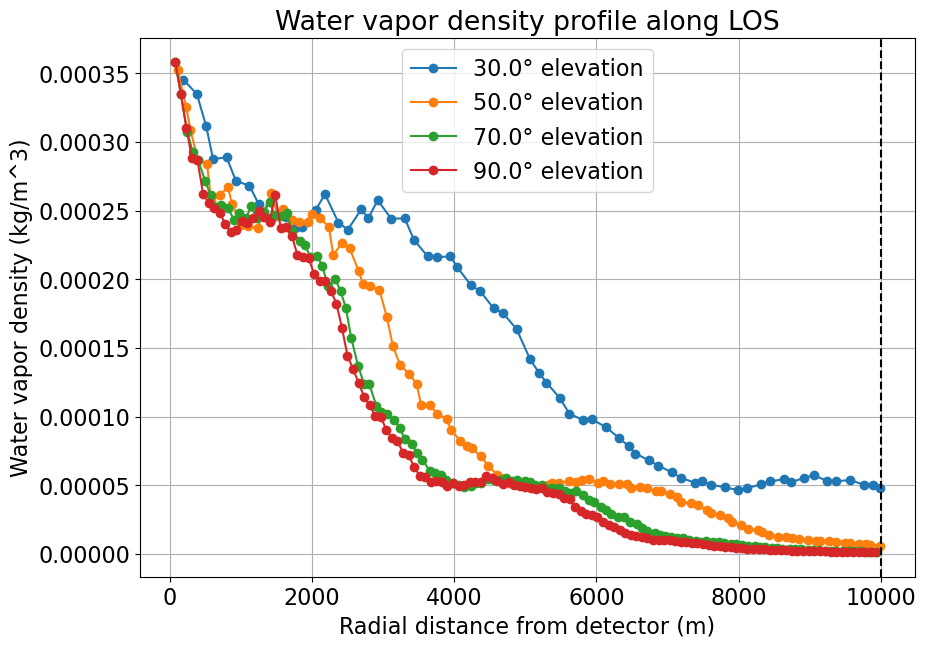

In [109]:
# --- Plot ---
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(10,7),dpi = 100)

for key in distance_dict.keys():
    radius = distance_dict[key]
    f = values_pwv_dict[key]
    # start at 0, cumulative sum of dr gives positions of each voxel
    # r = jnp.concatenate([jnp.array([0.0]), jnp.cumsum(dr)])  # shape (63,)


    plt.plot(radius, f, marker='o', label=f"{key}° elevation")

plt.axvline(max_radius, color='k', linestyle='--')
plt.xlabel("Radial distance from detector (m)")
plt.ylabel("Water vapor density (kg/m^3)")
plt.title("Water vapor density profile along LOS")
plt.grid(True)
plt.legend(loc='best')
plt.show()

In [110]:
def integrate_midpoint_approx(values, samples):
    return jnp.trapezoid(y = values, x = samples)

In [111]:
los_integral_pwv = {}
for key in distance_dict.keys():
    radius = distance_dict[key]
    f = values_pwv_dict[key]
    los_integral_pwv[key] = integrate_midpoint_approx(
        f,
        radius
    )

In [112]:
for key in distance_dict.keys():
    print(f"PWV along LOS at {key}° elevation: {los_integral_pwv[key]:.6f} kg/m^2")

PWV along LOS at 30.0° elevation: 1.504543 kg/m^2
PWV along LOS at 50.0° elevation: 1.058003 kg/m^2
PWV along LOS at 70.0° elevation: 0.873782 kg/m^2
PWV along LOS at 90.0° elevation: 0.821581 kg/m^2


In [113]:
voxels_indices_slices[voxels_indices_slices > 0]

Array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127], dtype=int64)